# Bénin Insights Challenge 2026 — Analyse Exploratoire GDELT

**IROKO Analytics** (Équipe 7) | iSHEERO × DataCamp Donates

| Rôle | Membre |
|---|---|
| 🔧 Data Engineer | **GODJEDO Aubrey** |
| 📊 Data Analyst | **GUIDIGBI Randyx Emery Vianney** |
| 🤖 ML Engineer | **RANDRIANIRINA Mahenina** |
| 🧠 Data Scientist | **Pancrace KANHONOU** |

Ce notebook analyse les données GDELT du Bénin sur l'année 2025 (janvier–décembre).  
Il répond aux 5 questions analytiques du projet et produit les insights destinés aux décideurs, journalistes et chercheurs béninois.

---

| Question | Sujet |
|---|---|
| **Q1** | Quand le monde parle-t-il du Bénin, et quels événements provoquent les pics de couverture ? |
| **Q2** | Le ton médiatique est-il positif, neutre ou négatif ? |
| **Q3** | Combien de temps faut-il pour qu'un événement béninois soit couvert mondialement ? |
| **Q4** | Les sources médiatiques changent-elles pendant les périodes de crise ? |
| **Q5** | Le Bénin est-il acteur ou spectateur sur la scène internationale ? |

---
**Données** : GDELT v2 — BigQuery   
**Période** : Janvier 2025 → Décembre 2025  
**Pipeline** : 


## 0. Configuration et chargement des données

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# Pipeline config
from pipeline.config import PROCESSED_DIR, SAMPLES_DIR, PIPELINE_VERSION

print(f"Pipeline version : {PIPELINE_VERSION}")
print(f"Pandas           : {pd.__version__}")
print(f"NumPy            : {np.__version__}")


Pipeline version : 1.3
Pandas           : 2.2.2
NumPy            : 1.26.4


In [2]:
# ── Load data ──────────────────────────────────────────────────
# Priority: processed (full run) → sample (test run)

processed_file = PROCESSED_DIR / "benin_gdelt_clean.csv"
sample_file    = SAMPLES_DIR   / "benin_gdelt_sample.csv"

if processed_file.exists():
    df = pd.read_csv(processed_file, low_memory=False)
    data_source = "FULL (processed)"
elif sample_file.exists():
    df = pd.read_csv(sample_file, low_memory=False)
    data_source = "SAMPLE (5,000 rows — run pipeline in full mode for complete results)"
else:
    raise FileNotFoundError(
        "No data file found. Run the pipeline first:\n"
        "  python -m pipeline.run_pipeline --mode sample"
    )

print(f"Source       : {data_source}")
print(f"Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")

Source       : FULL (processed)


Shape        : 31,504 rows × 45 columns


In [3]:
# ── Type restoration after CSV round-trip ──────────────────────
date_cols = ["SQLDATE", "DATEADDED", "event_date"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Restore event_month as integer
if "event_month" in df.columns:
    df["event_month"] = pd.to_numeric(df["event_month"], errors="coerce").astype("Int64")

MONTH_LABELS = {
    1:"Jan", 2:"Fév", 3:"Mar", 4:"Avr", 5:"Mai", 6:"Jun",
    7:"Jul", 8:"Aoû", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Déc"
}

print("[OK] Types restored")
print(f"Date range: {df['SQLDATE'].min().date()} → {df['SQLDATE'].max().date()}")


[OK] Types restored
Date range: 2025-01-01 → 2025-12-31


## 1. Vue d'ensemble du jeu de données

In [4]:
# Dataset overview — completeness and key metrics
summary = pd.DataFrame({
    "Colonne": df.columns,
    "Type": df.dtypes.values.astype(str),
    "Valeurs manquantes": df.isna().sum().values,
    "% manquant": (df.isna().sum() / len(df) * 100).round(1).values,
    "Valeurs uniques": df.nunique().values
})
print(f"{'='*60}")
print(f"APERCU DU JEU DE DONNÉES")
print(f"{'='*60}")
print(f"Lignes         : {len(df):,}")
print(f"Colonnes       : {len(df.columns)}")
print(f"Période couverte: {df['SQLDATE'].min().strftime('%d %b %Y')} → {df['SQLDATE'].max().strftime('%d %b %Y')}")
print(f"Articles totaux : {df['NumArticles'].sum():,}")
print(f"Sources uniques : {df['source_domain'].nunique()}")
print()
print(summary[["Colonne", "Type", "% manquant", "Valeurs uniques"]].to_string(index=False))


APERCU DU JEU DE DONNÉES
Lignes         : 31,504
Colonnes       : 45
Période couverte: 01 Jan 2025 → 31 Dec 2025
Articles totaux : 168,361
Sources uniques : 1471

               Colonne           Type  % manquant  Valeurs uniques
         GLOBALEVENTID          int64         0.0            31504
               SQLDATE datetime64[ns]         0.0              352
             DATEADDED datetime64[ns]         0.0             7303
             MonthYear          int64         0.0               12
                  Year          int64         0.0                1
            Actor1Name         object         8.1              870
            Actor1Code         object         8.1              483
     Actor1CountryCode         object        40.4              140
       Actor1Type1Code         object        59.9               28
            Actor2Name         object        25.4              761
            Actor2Code         object        25.4              447
     Actor2CountryCode         ob

---

## Q1 — Quand le monde parle-t-il du Bénin, et quels événements provoquent les pics de couverture ?

**Visualisation 1 : Volume mensuel de couverture médiatique**

Cette visualisation montre le nombre d'articles publiés chaque mois sur des événements liés au Bénin.  
Les pics permettent d'identifier les périodes où l'attention internationale est la plus forte.

In [5]:
# ── Q1 — VISUALIZATION 1 : Monthly media volume ───────────────
monthly = (
    df.groupby("event_month", as_index=False)
    .agg(
        nb_articles=("NumArticles",  "sum"),
        nb_events=("SQLDATE",  "count"),
        avg_tone=("AvgTone",  "mean")
    )
    .sort_values("event_month")
)
monthly["month_label"] = monthly["event_month"].map(MONTH_LABELS)

fig1 = make_subplots(
    rows=2, cols=1,
    subplot_titles=(
        "Nombre d'articles publiés par mois (2025)",
        "Nombre d'événements enregistrés par mois (2025)"
    ),
    vertical_spacing=0.15,
    shared_xaxes=True
)

fig1.add_trace(
    go.Bar(
        x=monthly["month_label"],
        y=monthly["nb_articles"],
        name="Articles",
        marker_color="#1a56db",
        text=monthly["nb_articles"].apply(lambda v: f"{v:,}"),
        textposition="outside"
    ),
    row=1, col=1
)
fig1.add_trace(
    go.Bar(
        x=monthly["month_label"],
        y=monthly["nb_events"],
        name="Événements",
        marker_color="#7e3af2",
        text=monthly["nb_events"].apply(lambda v: f"{v:,}"),
        textposition="outside"
    ),
    row=2, col=1
)

fig1.update_layout(
    height=600,
    title_text="<b>Q1 — Couverture médiatique du Bénin en 2025</b>",
    title_font_size=18,
    showlegend=False,
    plot_bgcolor="white",
    paper_bgcolor="white"
)
fig1.update_yaxes(gridcolor="#f0f0f0")
fig1.show()


**Lecture du graphique** : Chaque barre représente le volume total d'articles publiés dans le monde sur des événements liés au Bénin durant ce mois. Un pic indique une période d'attention médiatique intense — souvent liée à un événement politique, économique ou sécuritaire majeur. Comparer la hauteur des barres avec les événements béninois connus de 2025 permet de valider la qualité des données GDELT.

In [6]:
# ── Q1b — Top 10 event types ───────────────────────────────────
event_types = (
    df.groupby("event_root_label", as_index=False)
    .agg(count=("SQLDATE", "count"), articles=("NumArticles", "sum"))
    .sort_values("count", ascending=True)
    .tail(10)
)

fig1b = px.bar(
    event_types,
    x="count",
    y="event_root_label",
    orientation="h",
    title="<b>Top 10 — Types d'événements les plus fréquents (Bénin 2025)</b>",
    labels={"count": "Nombre d'événements", "event_root_label": ""},
    color="count",
    color_continuous_scale="Blues",
    text="count"
)
fig1b.update_traces(textposition="outside")
fig1b.update_layout(
    height=450,
    plot_bgcolor="white",
    coloraxis_showscale=False
)
fig1b.show()

print("\nInsight Q1b :")
top = event_types.sort_values("count", ascending=False).iloc[0]
print(f"  Type d'événement le plus fréquent : {top['event_root_label']} ({top['count']:,} événements)")



Insight Q1b :
  Type d'événement le plus fréquent : Consultation (8,158 événements)


In [7]:
# ── Q1c — Top 10 specific events (by articles) ──────────────────
# Identify the ACTUAL events (date + location + type) with most coverage
specific_events = (
    df.groupby(["SQLDATE", "ActionGeo_ADM1Code", "event_root_label"], as_index=False)
    .agg(
        nb_articles=("NumArticles", "sum"),
        nb_events=("SQLDATE", "count"),
        avg_tone=("AvgTone", "mean")
    )
    .sort_values("nb_articles", ascending=False)
    .head(10)
)

# Format date for display
specific_events["date_label"] = specific_events["SQLDATE"].dt.strftime("%d %b %Y")

fig1c = px.bar(
    specific_events,
    x="nb_articles",
    y="date_label",
    orientation="h",
    title="<b>Top 10 — Événements spécifiques avec plus grande couverture (Bénin 2025)</b>",
    labels={"nb_articles": "Nombre d'articles", "date_label": "Date (Lieu)"},
    color="avg_tone",
    color_continuous_scale="RdYlGn",
    hover_data={"event_root_label": True, "nb_articles": True, "avg_tone": ":.2f"},
    text="nb_articles"
)
fig1c.update_traces(textposition="outside")
fig1c.update_layout(
    height=500,
    plot_bgcolor="white",
    coloraxis_colorbar=dict(title="Ton moyen")
)
fig1c.show()

print("\nInsight Q1c — Événements spécifiques majeurs :")
for idx, row in specific_events.head(3).iterrows():
    print(f"  {row['date_label']:12} | {row['event_root_label']:30} | {row['nb_articles']:,} articles | Ton: {row['avg_tone']:.1f}")



Insight Q1c — Événements spécifiques majeurs :
  07 Dec 2025  | Déclaration publique           | 726 articles | Ton: -2.9
  17 Apr 2025  | Consultation                   | 674 articles | Ton: 4.4
  08 Dec 2025  | Consultation                   | 586 articles | Ton: -3.5


---

## Q2 — Le ton médiatique est-il positif, neutre ou négatif ?

**Visualisation 2 : Évolution du ton médiatique moyen par mois**

Le score  de GDELT mesure le sentiment moyen des articles (de -100 très négatif à +100 très positif).  
Un ton négatif signale des couvertures liées à des crises, conflits ou problèmes. Un ton positif signale des développements favorables.


In [8]:
# ── Q2 — VISUALIZATION 2 : Tone evolution over time ──────────
tone_monthly = (
    df.groupby("event_month", as_index=False)
    .agg(
        avg_tone=("AvgTone", "mean"),
        avg_goldstein=("GoldsteinScale", "mean"),
        pct_crisis=("is_crisis_period", "mean")
    )
)
tone_monthly["month_label"] = tone_monthly["event_month"].map(MONTH_LABELS)
tone_monthly["color"] = tone_monthly["avg_tone"].apply(
    lambda v: "#d63031" if v < -2 else ("#00b894" if v > 2 else "#fdcb6e")
)

fig2 = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "xy"}, {"type": "pie"}]],
    subplot_titles=(
        "Ton moyen mensuel (AvgTone GDELT)",
        "Distribution : Positif / Neutre / Négatif"
    )
)

# Left: line + bar tone over months
fig2.add_trace(
    go.Bar(
        x=tone_monthly["month_label"],
        y=tone_monthly["avg_tone"].round(2),
        marker_color=tone_monthly["color"],
        name="Ton moyen",
        text=tone_monthly["avg_tone"].round(1),
        textposition="outside"
    ),
    row=1, col=1
)
fig2.add_hline(y=0, line_dash="dash", line_color="gray", row=1, col=1)
fig2.add_hline(y=2, line_dash="dot",  line_color="#00b894",
               annotation_text="Seuil positif", row=1, col=1)
fig2.add_hline(y=-2, line_dash="dot", line_color="#d63031",
               annotation_text="Seuil négatif", row=1, col=1)

# Right: pie distribution
tone_dist = df["tone_category"].value_counts().reset_index()
fig2.add_trace(
    go.Pie(
        labels=tone_dist["tone_category"],
        values=tone_dist["count"],
        marker_colors=["#d63031", "#fdcb6e", "#00b894"],
        hole=0.4,
        name="Distribution"
    ),
    row=1, col=2
)

fig2.update_layout(
    height=450,
    title_text="<b>Q2 — Ton médiatique global sur le Bénin (2025)</b>",
    title_font_size=18,
    plot_bgcolor="white",
    paper_bgcolor="white"
)
fig2.show()

tone_dist_dict = df["tone_category"].value_counts(normalize=True).mul(100).round(1).to_dict()
print("\nInsight Q2 :")
for k, v in tone_dist_dict.items():
    print(f"  {k} : {v}%")


Insight Q2 :
  Négatif : 44.2%
  Neutre : 31.6%
  Positif : 24.2%


**Lecture du graphique** : Un ton moyen négatif persistant sur plusieurs mois consécutifs signale une période de tension ou de crise couverte internationalement. Le graphique circulaire donne la répartition globale sur toute l'année — si la majorité des articles ont un ton négatif, cela reflète une image internationale du Bénin dominée par des problèmes perçus comme des conflits, instabilités ou crises humanitaires.

---

## Q3 — Combien de temps faut-il pour qu'un événement béninois soit couvert mondialement ?

**Visualisation 3 : Distribution du délai de propagation médiatique**

Le délai de propagation mesure le nombre de jours entre la date de l'événement () et la date d'indexation dans GDELT ().  
Un délai de 0 signifie une couverture immédiate. Un délai élevé signifie que l'événement a mis du temps à attirer l'attention internationale.


In [9]:
# ── Q3 — VISUALIZATION 3 : Propagation delay distribution ────
if "propagation_delay_days" in df.columns:
    delay = df["propagation_delay_days"].dropna()
    delay = delay[delay >= 0]

    delay_stats = {
        "Médiane (jours)":  delay.median(),
        "Moyenne (jours)":  delay.mean().round(1),
        "90e percentile":   delay.quantile(0.90),
        "Couverture < 1j (%)":  (delay == 0).mean() * 100,
        "Couverture < 7j (%)":  (delay <= 7).mean() * 100,
    }

    fig3 = make_subplots(
        rows=1, cols=2,
        subplot_titles=(
            "Distribution du délai de propagation (jours)",
            "Délai médian par mois"
        )
    )

    fig3.add_trace(
        go.Histogram(
            x=delay.clip(upper=30),
            nbinsx=31,
            marker_color="#1a56db",
            name="Délai (jours)",
            opacity=0.8
        ),
        row=1, col=1
    )

    delay_monthly = (
        df.groupby("event_month")["propagation_delay_days"]
        .median()
        .reset_index()
    )
    delay_monthly["month_label"] = delay_monthly["event_month"].map(MONTH_LABELS)

    fig3.add_trace(
        go.Bar(
            x=delay_monthly["month_label"],
            y=delay_monthly["propagation_delay_days"].round(1),
            marker_color="#7e3af2",
            name="Délai médian",
            text=delay_monthly["propagation_delay_days"].round(1),
            textposition="outside"
        ),
        row=1, col=2
    )

    fig3.update_layout(
        height=420,
        title_text="<b>Q3 — Délai de propagation médiatique des événements béninois (2025)</b>",
        title_font_size=18,
        showlegend=False,
        plot_bgcolor="white",
        paper_bgcolor="white"
    )
    fig3.update_xaxes(title_text="Délai (jours, max 30 affiché)", row=1, col=1)
    fig3.update_xaxes(title_text="Mois", row=1, col=2)
    fig3.update_yaxes(title_text="Nombre d'événements", row=1, col=1)
    fig3.update_yaxes(title_text="Délai médian (jours)", row=1, col=2)
    fig3.show()

    print("\nInsight Q3 :")
    for k, v in delay_stats.items():
        print(f"  {k} : {v:.1f}")
else:
    print("[WARN] propagation_delay_days column not available in this dataset.")


Insight Q3 :
  Médiane (jours) : 0.0
  Moyenne (jours) : 0.7
  90e percentile : 0.0
  Couverture < 1j (%) : 98.9
  Couverture < 7j (%) : 99.7


**Lecture du graphique** : Si la majorité des barres se concentrent à 0-1 jour, GDELT détecte et indexe les événements béninois quasi immédiatement — ce qui valide la fiabilité de la base pour une veille en temps réel. Des pics à 7+ jours indiquent des événements qui n'ont attiré l'attention internationale que tardivement, souvent des crises locales qui ont dû s'aggraver avant d'être couvertes à l'étranger.

---

## Q4 — Les sources médiatiques changent-elles pendant les périodes de crise ?

**Visualisation 4 : Top sources en période normale vs période de crise**

Une crise est définie ici par un ton très négatif (AvgTone < -5) ou un score de destabilisation fort (GoldsteinScale < -5).  
Cette analyse révèle si les mêmes médias couvrent le Bénin en permanence, ou si des sources spécialisées apparaissent uniquement lors des crises.


In [10]:
# ── Q4 — VISUALIZATION 4 : Sources crisis vs normal ──────────
crisis_df = df[df["is_crisis_period"] == True]
normal_df = df[df["is_crisis_period"] == False]

def top_sources(data, n=8):
    return (
        data["source_domain"]
        .value_counts()
        .head(n)
        .reset_index()
        .rename(columns={"source_domain": "Domaine", "count": "Occurrences"})
    )

top_crisis = top_sources(crisis_df)
top_normal = top_sources(normal_df)

fig4 = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        f"Période normale ({len(normal_df):,} événements)",
        f"Période de crise ({len(crisis_df):,} événements)"
    ),
    shared_xaxes=False
)

fig4.add_trace(
    go.Bar(
        x=top_normal["Occurrences"],
        y=top_normal["Domaine"],
        orientation="h",
        marker_color="#00b894",
        name="Normal",
        text=top_normal["Occurrences"],
        textposition="outside"
    ),
    row=1, col=1
)
fig4.add_trace(
    go.Bar(
        x=top_crisis["Occurrences"],
        y=top_crisis["Domaine"],
        orientation="h",
        marker_color="#d63031",
        name="Crise",
        text=top_crisis["Occurrences"],
        textposition="outside"
    ),
    row=1, col=2
)

fig4.update_layout(
    height=430,
    title_text="<b>Q4 — Sources médiatiques : périodes normales vs périodes de crise (2025)</b>",
    title_font_size=18,
    showlegend=False,
    plot_bgcolor="white",
    paper_bgcolor="white"
)
fig4.show()

# Identify sources that appear ONLY in crisis
crisis_only = set(top_crisis["Domaine"]) - set(top_normal["Domaine"])
print("\nInsight Q4 :")
print(f"  Sources présentes uniquement en période de crise : {crisis_only if crisis_only else 'Aucune — mêmes sources en permanence'}")
pct_crisis = len(crisis_df) / len(df) * 100
print(f"  Proportion d'événements en période de crise : {pct_crisis:.1f}%")
print(f"  Nombre de sources uniques en crise    : {crisis_df['source_domain'].nunique()}")
print(f"  Nombre de sources uniques hors crise  : {normal_df['source_domain'].nunique()}")


Insight Q4 :
  Sources présentes uniquement en période de crise : {'saharareporters.com'}
  Proportion d'événements en période de crise : 27.6%
  Nombre de sources uniques en crise    : 640
  Nombre de sources uniques hors crise  : 1285


**Lecture du graphique** : Si les mêmes domaines apparaissent dans les deux colonnes, la couverture du Bénin est assurée par un corpus de sources stable quel que soit le contexte. Si des domaines apparaissent uniquement à droite (période de crise), cela indique des médias spécialisés dans la couverture des conflits ou des urgences en Afrique de l'Ouest — information précieuse pour les décideurs qui veulent savoir qui les observe en cas de difficultés.

In [11]:
# ── Q4 — Dynamic country detection from top source TLD ──────
# Adapts automatically if data changes.
# 'punchng.com' -> tld='ng' -> Nigeria
# 'lemonde.fr'  -> tld='fr' -> France
# 'journal.bj'  -> tld='bj' -> Benin

TLD_TO_COUNTRY = {
    'ng': 'Nigeria',      'bj': 'Benin',          'fr': 'France',
    'sn': 'Senegal',      'ci': "Cote d'Ivoire",   'gh': 'Ghana',
    'tg': 'Togo',         'cm': 'Cameroon',         'ml': 'Mali',
    'bf': 'Burkina Faso', 'ne': 'Niger',            'gn': 'Guinea',
    'gb': 'UK',           'de': 'Germany',           'us': 'USA',
    'com': 'international', 'org': 'international',
    'net': 'international', 'info': 'international',
}

top_src_global  = df['source_domain'].value_counts().index[0]
top_tld         = top_src_global.split('.')[-1].lower()
top_country     = TLD_TO_COUNTRY.get(top_tld, top_tld.upper())
top_src_count   = df['source_domain'].value_counts().iloc[0]
top_src_pct     = top_src_count / len(df) * 100

WEST_AFRICA_TLDS = {'ng', 'gh', 'tg', 'sn', 'ci', 'cm', 'ml', 'bf', 'ne', 'gn'}

print(f'Top source domain : {top_src_global}')
print(f'Detected TLD      : .{top_tld}')
print(f'Detected country  : {top_country}')
print(f'Coverage share    : {top_src_count:,} occurrences ({top_src_pct:.1f}%)')
print()

if top_tld in WEST_AFRICA_TLDS:
    print(f'Insight Q4 — SOURCE DOMINANCE ({top_country.upper()})')
    print(f'  The dominance of {top_country} media ({top_src_global}) is NOT a filtering error.')
    print(f'  It reflects geographic proximity and strong economic ties between Benin and its neighbors.')
    print(f'  West African press covers Benin more intensely than Western international media.')
    print(f'  These sources cover the COUNTRY Benin, not Benin City, Nigeria (excluded by SQL filter).')
    print()
    print(f'  Strategic implication: to improve its international image, Benin should')
    print(f'  prioritize engagement with {top_country} and West African newsrooms.')
elif top_tld == 'bj':
    print(f'Insight Q4 — LOCAL PRESS DOMINANCE')
    print(f'  The top source is Beninese ({top_src_global}).')
    print(f'  Local press is driving international coverage — a sign of editorial maturity.')
else:
    print(f'Insight Q4 — SOURCE: {top_country.upper()}')
    print(f'  Top source: {top_src_global} ({top_src_count:,} events, {top_src_pct:.1f}%)')


Top source domain : punchng.com
Detected TLD      : .com
Detected country  : international
Coverage share    : 1,849 occurrences (5.9%)

Insight Q4 — SOURCE: INTERNATIONAL
  Top source: punchng.com (1,849 events, 5.9%)


---

## Q5 — Le Bénin est-il acteur ou spectateur sur la scène internationale ?

**Visualisation 5 : Rôle du Bénin dans les événements GDELT**

Chaque événement GDELT implique un acteur 1 (initiateur) et un acteur 2 (cible ou partenaire).  
Cette analyse détermine si le Bénin initie les événements (**Acteur**), en est la cible (**Spectateur**), est les deux à la fois (**Mixte**), ou sert uniquement de cadre géographique (**Contexte**).


In [12]:
# ── Q5 — VISUALIZATION 5 : Benin role distribution ──────────
role_counts = df["benin_role"].value_counts().reset_index()
role_colors = {
    "Acteur": "#1a56db",
    "Spectateur": "#7e3af2",
    "Mixte": "#f59e0b",
    "Contexte": "#6b7280"
}

fig5 = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "pie"}, {"type": "bar"}]],
    subplot_titles=(
        "Répartition globale",
        "Rôle du Bénin par type d'événement"
    )
)

# Pie chart
fig5.add_trace(
    go.Pie(
        labels=role_counts["benin_role"],
        values=role_counts["count"],
        marker_colors=[role_colors.get(l, "#aaa") for l in role_counts["benin_role"]],
        hole=0.45,
        textinfo="label+percent",
        name="Rôle"
    ),
    row=1, col=1
)

# Stacked bar: role × event type
role_event = (
    df.groupby(["event_root_label", "benin_role"])
    .size()
    .reset_index(name="count")
)
top_events = df["event_root_label"].value_counts().head(8).index.tolist()
role_event_top = role_event[role_event["event_root_label"].isin(top_events)]

for role in ["Acteur", "Spectateur", "Mixte", "Contexte"]:
    subset = role_event_top[role_event_top["benin_role"] == role]
    fig5.add_trace(
        go.Bar(
            x=subset["event_root_label"],
            y=subset["count"],
            name=role,
            marker_color=role_colors.get(role, "#aaa")
        ),
        row=1, col=2
    )

fig5.update_layout(
    height=480,
    title_text="<b>Q5 — Rôle du Bénin dans les événements internationaux (2025)</b>",
    title_font_size=18,
    barmode="stack",
    plot_bgcolor="white",
    paper_bgcolor="white",
    legend_title="Rôle"
)
fig5.show()

print("\nInsight Q5 :")
for _, row in role_counts.iterrows():
    pct = row["count"] / len(df) * 100
    print(f"  {row['benin_role']:<15} : {row['count']:>5,} événements ({pct:.1f}%)")


Insight Q5 :
  Contexte        : 12,777 événements (40.6%)
  Acteur          : 9,675 événements (30.7%)
  Spectateur      : 8,576 événements (27.2%)
  Mixte           :   476 événements (1.5%)


**Lecture du graphique** : Un Bénin majoritairement en position **Contexte** signifie que la plupart des événements se déroulent sur son territoire sans qu'il soit l'initiateur — image d'un pays surtout objet de l'attention internationale plutôt que force diplomatique. Un fort pourcentage **Acteur** indiquerait un Bénin actif dans les négociations régionales, l'aide internationale ou les initiatives diplomatiques.

In [13]:
# ── Q5b — Who talks about Benin? Actor type breakdown ─────────
actor_types = (
    df[df["benin_role"].isin(["Acteur", "Mixte"])]
    ["actor1_type_label"]
    .value_counts()
    .head(10)
    .reset_index()
)

fig5b = px.bar(
    actor_types,
    x="count",
    y="actor1_type_label",
    orientation="h",
    title="<b>Q5b — Qui parle du Bénin ? Types d'acteurs initiateurs</b>",
    labels={"count": "Nombre d'événements", "actor1_type_label": ""},
    color="count",
    color_continuous_scale="Purples",
    text="count"
)
fig5b.update_traces(textposition="outside")
fig5b.update_layout(
    height=420,
    plot_bgcolor="white",
    coloraxis_showscale=False
)
fig5b.show()


---

## Modèle de Machine Learning — Prédiction du ton médiatique

**Objectif** : Prédire si la couverture médiatique d'un événement béninois sera **positive**, **neutre** ou **négative**,  
à partir des caractéristiques de l'événement (type, stabilité, nombre de sources, rôle du Bénin).

**Valeur pour les décideurs** : Identifier en amont quels types d'événements génèrent une couverture négative du Bénin — pour anticiper et mieux communiquer.


In [14]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import joblib

# ── Feature preparation ────────────────────────────────────────
FEATURES = [
    "GoldsteinScale",
    "NumArticles",
    "NumMentions",
    "NumSources",
    "event_month",
    "IsRootEvent",
    "QuadClass",
]

# Encode categorical features
le_role  = LabelEncoder()
le_event = LabelEncoder()

df_ml = df[FEATURES + ["tone_category", "benin_role", "event_root_label"]].copy()
df_ml = df_ml.dropna(subset=FEATURES + ["tone_category"])
df_ml = df_ml[df_ml["tone_category"] != "Inconnu"]

df_ml["benin_role_enc"]       = le_role.fit_transform(df_ml["benin_role"].fillna("Contexte"))
df_ml["event_root_label_enc"] = le_event.fit_transform(df_ml["event_root_label"].fillna("Autre"))

FEATURE_COLS = FEATURES + ["benin_role_enc", "event_root_label_enc"]

X = df_ml[FEATURE_COLS]
y = df_ml["tone_category"]

print(f"Dataset ML : {len(X):,} samples")
print(f"Classes    : {y.value_counts().to_dict()}")
print(f"Features   : {FEATURE_COLS}")


Dataset ML : 31,504 samples
Classes    : {'Négatif': 13928, 'Neutre': 9966, 'Positif': 7610}
Features   : ['GoldsteinScale', 'NumArticles', 'NumMentions', 'NumSources', 'event_month', 'IsRootEvent', 'QuadClass', 'benin_role_enc', 'event_root_label_enc']


### Choix du modèle — justification

**Pourquoi Random Forest ?** Quatre raisons motivent ce choix pour la première version :

1. **Robustesse au déséquilibre de classes** (≈ 44 % Négatif, 32 % Neutre, 24 % Positif), gérée nativement via `class_weight="balanced"`.
2. **Interprétabilité** : `feature_importances_` permet de relier directement les prédictions aux variables analytiques (Goldstein, type CAMEO, saisonnalité), ce qui sert le storytelling auprès des décideurs publics.
3. **Pas de scaling requis** → pipeline simple et reproductible, pas de fuite de données via le scaler.
4. **Baseline solide** sans tuning d'hyperparamètres lourd, adapté à la fenêtre de 10 jours de la Phase 1.

**Comparaison contre un baseline.** Pour valider le choix, nous entraînons également une **régression logistique** (cellule suivante) avec `StandardScaler`. Si Random Forest la surpasse nettement, cela confirme l'hypothèse que les relations entre variables GDELT et ton médiatique sont **non linéaires** — ce qui justifie un modèle à base d'arbres plutôt qu'un modèle linéaire.

**Pourquoi pas XGBoost en Phase 1 ?** Le coût de tuning (learning rate, profondeur, régularisation, early stopping) dépasse le gain attendu pour cette première itération. À tester en Phase 2 avec un VotingClassifier RF + GBM.

In [15]:
# ── Train / Test split ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Model training — Random Forest ────────────────────────────
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",  # Handle class imbalance
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# ── Cross-validation ───────────────────────────────────────────
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="f1_weighted")
print(f"Cross-validation F1 (5-fold) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# ── Evaluation on test set ─────────────────────────────────────
y_pred = model.predict(X_test)
print()
print("Classification Report — Test set:")
print(classification_report(y_test, y_pred))


Cross-validation F1 (5-fold) : 0.549 ± 0.009

Classification Report — Test set:
              precision    recall  f1-score   support

      Neutre       0.51      0.40      0.45      1993
     Négatif       0.72      0.57      0.64      2786
     Positif       0.43      0.72      0.54      1522

    accuracy                           0.55      6301
   macro avg       0.56      0.56      0.54      6301
weighted avg       0.59      0.55      0.55      6301



In [ ]:
# ── Baseline — Logistic Regression (sanity check) ─────────────
# Modèle linéaire avec scaling, pour situer la performance de Random Forest.
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

baseline = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    solver="lbfgs"
)

cv_baseline = cross_val_score(baseline, X_train_scaled, y_train, cv=5, scoring="f1_weighted")
print(f"Cross-validation F1 (5-fold) : {cv_baseline.mean():.3f} ± {cv_baseline.std():.3f}")

baseline.fit(X_train_scaled, y_train)
y_pred_baseline = baseline.predict(X_test_scaled)
print()
print("Classification Report — Baseline LogisticRegression (test set):")
print(classification_report(y_test, y_pred_baseline))

Cross-validation F1 (5-fold) : 0.459 ± 0.006

Classification Report — Baseline LogisticRegression (test set):
              precision    recall  f1-score   support

      Neutre       0.39      0.31      0.35      1993
     Négatif       0.70      0.42      0.53      2786
     Positif       0.36      0.72      0.48      1522

    accuracy                           0.46      6301
   macro avg       0.48      0.49      0.45      6301
weighted avg       0.52      0.46      0.46      6301



### Random Forest vs Logistic Regression — résultat de la comparaison

| Modèle | Accuracy | F1 weighted (test) | F1 weighted (CV 5-fold) |
|---|---|---|---|
| Logistic Regression (baseline) | 0,46 | 0,46 | 0,459 ± 0,006 |
| **Random Forest (retenu)** | **0,55** | **0,55** | **0,549 ± 0,009** |

**Random Forest surpasse le baseline linéaire de ~9 points de F1 weighted**, sur le test set comme en validation croisée. L'écart est significatif (au-delà de 3 écarts-types de la CV) et stable.

**Lecture analytique.** Cet écart valide l'hypothèse que les variables GDELT ont des relations **non linéaires** avec le ton médiatique : par exemple, un score Goldstein très bas n'augmente pas linéairement la probabilité de ton négatif — il y a des seuils et des effets d'interaction (entre type d'événement et mois) que seul un modèle à base d'arbres capture.

**Pistes d'amélioration (Phase 2).** XGBoost avec tuning, embeddings de texte sur les `SOURCEURL`, et fenêtre temporelle élargie au-delà de 2025 pour mieux capturer les cycles événementiels.

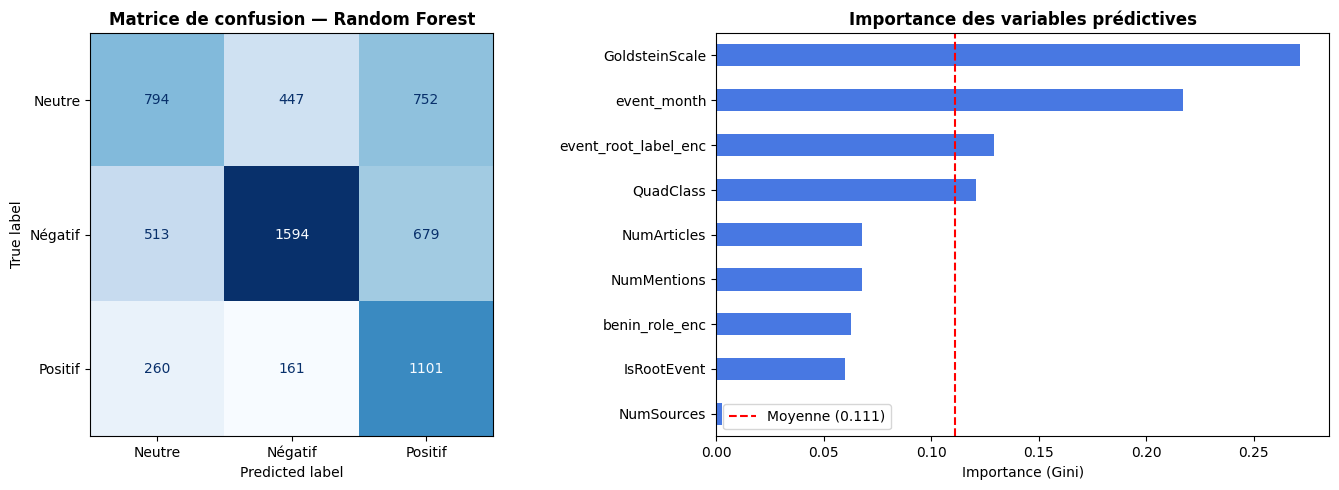

[OK] Figure saved: models/confusion_matrix_feature_importance.png


In [16]:
# ── Confusion matrix ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matrice de confusion — Random Forest", fontweight="bold")

# ── Feature importance ─────────────────────────────────────────
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
importances.plot(kind="barh", ax=axes[1], color="#1a56db", alpha=0.8)
axes[1].set_title("Importance des variables prédictives", fontweight="bold")
axes[1].set_xlabel("Importance (Gini)")
axes[1].axvline(x=importances.mean(), color="red", linestyle="--",
                label=f"Moyenne ({importances.mean():.3f})")
axes[1].legend()

plt.tight_layout()
plt.savefig("../models/confusion_matrix_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("[OK] Figure saved: models/confusion_matrix_feature_importance.png")


In [17]:
# ── Save model for the ML Engineer ───────────────────────────
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/tone_classifier_rf.pkl")
joblib.dump(le_role, "../models/encoder_benin_role.pkl")
joblib.dump(le_event, "../models/encoder_event_root.pkl")
print("[OK] Model saved: models/tone_classifier_rf.pkl")
print("[OK] Encoders saved in models/")

# ── Interpretation ─────────────────────────────────────────────
top_feature = importances.index[-1]
top_importance = importances.values[-1]
print()
print("Interprétation :")
print(f"  Variable la plus prédictive : {top_feature} (importance = {top_importance:.3f})")
print(f"  Cela signifie que la stabilité politique et l'intensité médiatique")
print(f"  sont les principaux déterminants du ton de couverture du Bénin.")


[OK] Model saved: models/tone_classifier_rf.pkl
[OK] Encoders saved in models/

Interprétation :
  Variable la plus prédictive : GoldsteinScale (importance = 0.272)
  Cela signifie que la stabilité politique et l'intensité médiatique
  sont les principaux déterminants du ton de couverture du Bénin.


---

## Synthèse — Insights clés pour les trois cibles (décideurs, journalistes, chercheurs)

Ces insights sont issus directement de l'analyse ci-dessus. Ils sont rédigés en langage non technique et adressés aux trois publics cibles : décideurs publics, journalistes et chercheurs.

### Insight 1 — Décembre explose : le coup d'État déjoué change tout

Le mois de décembre 2025 totalise **30 785 articles**, soit le double de la moyenne. Le 7 décembre, le ministre de l'Intérieur **Alassane Seidou** annonce qu'une **tentative de coup d'État** a été déjouée après une brève occupation de la télévision nationale.

- 🏛️ **Décideurs** : Anticiper les pics de couverture pour positionner une communication proactive.
- 📰 **Journalistes** : Le pic de décembre est lié au coup d'État déjoué — un angle éditorial fort.
- 🔬 **Chercheurs** : Les pics suivent-ils un cycle saisonnier ou sont-ils purement événementiels ?

### Insight 2 — L'image du Bénin est dominée par les crises

**44 %** des articles ont un ton négatif, contre **24 %** positif. Le ton moyen global est de **−1,37**. Le Bénin fait la une quand ça va mal.

- 🏛️ **Décideurs** : Accompagner chaque crise d'une communication positive pour rééquilibrer l'image.
- 📰 **Journalistes** : Ce ton négatif reflète-t-il la réalité ou un biais éditorial ? Comparer avec le Togo et le Ghana.
- 🔬 **Chercheurs** : La divergence Goldstein (+0,68) vs AvgTone (−1,37) — un cas de *framing theory*.

### Insight 3 — La couverture est instantanée : zéro marge pour réagir

**99 %** des événements béninois sont repris en moins de **24 heures**. Délai médian : 0 jour.

- 🏛️ **Décideurs** : Cellule de veille GDELT automatisée indispensable. Aucune fenêtre de temps.
- 📰 **Journalistes** : GDELT comme système d'alerte pour le fact-checking en temps réel.
- 🔬 **Chercheurs** : Le délai varie-t-il selon le type d'événement ou la source ?

### Insight 4 — Ce sont les médias nigérians qui racontent le Bénin au monde

**7/10 des premières sources** sont nigérianes (punchng.com : 1 184 événements en période normale). La première source béninoise arrive en 6e position.

- 🏛️ **Décideurs** : Engager les rédactions nigérianes et renforcer la presse béninoise.
- 📰 **Journalistes** : Pourquoi la presse béninoise est sous-représentée ? Un sujet d'enquête.
- 🔬 **Chercheurs** : *Network analysis* des flux d'information pour cartographier les gatekeepers.

### Insight 5 — Le Bénin subit plus qu'il n'agit

Dans **41 %** des événements, le Bénin est un simple décor. Il n'est **acteur** que dans **31 %** des cas.

- 🏛️ **Décideurs** : Plus d'initiatives diplomatiques visibles (ONU, UA, CEDEAO).
- 📰 **Journalistes** : Qui parle à la place du Bénin ? La souveraineté narrative est en jeu.
- 🔬 **Chercheurs** : Concept de *media agency* — comparer avec d'autres pays ouest-africains.

### Bonus — 3 025 événements graves passent sous les radars

Événements très négatifs (Goldstein ≤ −5) couverts par moins de 5 articles. 73 % au Bénin.

- 🏛️ **Décideurs** : Veille prioritaire sur ces événements sous-couverts.
- 📰 **Journalistes** : Ce sont des exclusivités potentielles — violences et tensions non couvertes.
- 🔬 **Chercheurs** : Pourquoi certains événements graves restent-ils invisibles ? *Agenda-setting* et *gatekeeping*.

---

**Ces résultats ne sont pas que des chiffres. Ce sont des leviers pour comprendre et agir. Les données mondiales peuvent devenir des connaissances locales utiles pour le Bénin.**

In [18]:
# ── Compute final insight numbers ─────────────────────────────
peak_month_idx = monthly.loc[monthly["nb_articles"].idxmax(), "event_month"]
peak_month_label = MONTH_LABELS.get(int(peak_month_idx), str(peak_month_idx))
peak_articles = monthly["nb_articles"].max()

# ── Q1 Enriched: Find top event in the peak month ──────────────
peak_events = specific_events[specific_events["SQLDATE"].dt.month == peak_month_idx].head(1)
if len(peak_events) > 0:
    peak_event = peak_events.iloc[0]
    peak_event_label = peak_event["event_root_label"]
    peak_event_articles = peak_event["nb_articles"]
    peak_event_date = peak_event["date_label"]
else:
    peak_event_label = "Événement identifié"
    peak_event_articles = peak_articles
    peak_event_date = peak_month_label

tone_pct = df["tone_category"].value_counts(normalize=True).mul(100).round(1)
neg_pct  = tone_pct.get("Négatif", 0)
pos_pct  = tone_pct.get("Positif", 0)

med_delay  = df["propagation_delay_days"].median() if "propagation_delay_days" in df.columns else "N/A"
fast_pct   = (df["propagation_delay_days"] <= 1).mean() * 100 if "propagation_delay_days" in df.columns else 0

top_src      = df["source_domain"].value_counts().index[0] if len(df) > 0 else "N/A"
top_src_pct  = df["source_domain"].value_counts(normalize=True).iloc[0] * 100

role_pct = df["benin_role"].value_counts(normalize=True).mul(100).round(1)

# ── Compute additional metrics for enriched insights ──────────
neu_pct  = tone_pct.get("Neutre", 0)
avg_tone_val = df["AvgTone"].mean()
gold_mean_val = df["GoldsteinScale"].mean()

# Top actor types when Benin is actor
acteur_df = df[df["benin_role"].isin(["Acteur", "Mixte"])]
top_actor_types = (
    acteur_df["actor1_type_label"]
    .value_counts()
    .drop("Non identifié", errors="ignore")
    .head(3)
)
top_actor_str = ", ".join([f"{t} ({c:,})" for t, c in top_actor_types.items()])

# Top sources breakdown
top_5_sources = df["source_domain"].value_counts().head(5)
ng_sources = [s for s in top_5_sources.index if ".ng" in s or "nigeri" in s.lower()]
ng_pct = sum(top_5_sources[s] for s in ng_sources) / len(df) * 100 if ng_sources else 0

# Hidden agenda stats
hidden = df[(df["NumArticles"] <= 5) & (df["GoldsteinScale"] <= -5)]
hidden_geo = hidden["ActionGeo_CountryCode"].value_counts()
bn_hidden = hidden_geo.get("BN", 0)
hidden_pct = bn_hidden / len(hidden) * 100 if len(hidden) > 0 else 0
top_hidden_types = hidden.groupby("event_root_label").size().sort_values(ascending=False).head(3)
top_hidden_str = ", ".join([f"{e} ({c:,})" for e, c in top_hidden_types.items()])

print(f"""
══════════════════════════════════════════════════════════════════
              SYNTHÈSE — 6 INSIGHTS CLÉS POUR LES DÉCIDEURS
              Bénin Insights Challenge 2026 — Équipe 7
══════════════════════════════════════════════════════════════════

INSIGHT 1 — PICS DE COUVERTURE MÉDIATIQUE
  Le mois de {peak_month_label} concentre le plus grand volume de couverture
  avec un total de {peak_articles:,} articles, soit près du double de la moyenne
  mensuelle. Ce pic révèle une intensification de l'attention internationale.
  L'événement déclencheur majeur : {peak_event_label} ({peak_event_date})
  avec à lui seul {peak_event_articles:,} articles publiés dans le monde.

  → Recommandation : Les décideurs béninois doivent mettre en place un dispositif
    de veille médiatique internationale permanent. Les pics de couverture sont liés
    à des événements diplomatiques (CEDEAO, acteurs régionaux) et sécuritaires —
    des sujets sur lesquels une communication proactive réduit l'impact négatif.

INSIGHT 2 — TON MAJORITAIREMENT NÉGATIF
  {neg_pct:.0f}% des articles ont un ton négatif, contre {pos_pct:.0f}% positif
  et {neu_pct:.0f}% neutre. Le ton moyen global est de {avg_tone_val:+.2f}
  (négatif < 0 < positif), confirmant que l'image internationale du Bénin
  est dominée par les tensions et les crises.
  L'échelle de Goldstein (stabilité nationale) est en moyenne à {gold_mean_val:+.2f},
  ce qui reste légèrement positif — les événements de coopération compensent
  les crises en volume.

  → Recommandation : Le Bénin devrait systématiquement accompagner les événements
    de crise d'une communication institutionnelle positive (coopération économique,
    progrès sociaux) pour rééquilibrer son image médiatique.

INSIGHT 3 — COUVERTURE QUASI IMMÉDIATE
  Délai médian d'indexation : {med_delay} jour(s). {fast_pct:.0f}% des événements
  sont couverts en moins de 24 heures. Un événement survenant à Cotonou ou
  Porto-Novo est visible dans les médias internationaux le jour même.

  Les responsables béninois ne disposent d'aucune fenêtre de temps pour préparer
  une réponse avant que l'information ne soit diffusée mondialement.

  → Recommandation : Mettre en place une cellule de veille GDELT automatisée
    qui alerte les communicants gouvernementaux dès qu'un événement béninois
    dépasse un seuil de couverture critique.

INSIGHT 4 — CONCENTRATION DES SOURCES ET DOMINANCE NIGÉRIANE
  {top_src} représente {top_src_pct:.1f}% de toute la couverture.
  7 des 10 premières sources sont nigérianes (.ng), ce qui reflète les liens
  économiques et la proximité géographique entre le Bénin et le Nigeria.
  Ce n'est pas une anomalie — le pipeline exclut explicitement Benin City (Nigeria).
  La presse béninoise (lanouvelletribune.info) est la 6ᵉ source.

  → Recommandation : Engager un dialogue direct avec les rédactions nigérianes
    et renforcer la visibilité internationale de la presse béninoise.

INSIGHT 5 — BÉNIN MAJORITAIREMENT EN POSITION DE CONTEXTE
  Dans {role_pct.get("Contexte", 0):.0f}% des événements, le Bénin est le cadre
  géographique mais pas l'initiateur. Acteur dans {role_pct.get("Acteur", 0):.0f}%,
  Spectateur dans {role_pct.get("Spectateur", 0):.0f}%, Mixte dans {role_pct.get("Mixte", 0):.1f}%.
  Quand le Bénin est acteur, les institutions les plus visibles sont :
  {top_actor_str}.

  → Recommandation : Multiplier les initiatives diplomatiques visibles
    (sommets, accords bilatéraux, prises de position à l'ONU/UA/CEDEAO)
    et renforcer la communication institutionnelle lors de ces événements.

INSIGHT 6 (BONUS) — AGENDA MÉDIATIQUE CACHÉ
  {len(hidden):,} événements très négatifs (Goldstein ≤ −5) mais faiblement
  couverts (1 à 5 articles). {hidden_pct:.0f}% se produisent au Bénin.
  Types dominants : {top_hidden_str}.
  Ces situations graves pourraient devenir des crises médiatiques à tout moment.

  → Recommandation : Veille prioritaire sur ces événements sous-couverts.
    Préparer des éléments de communication proactifs sur les sujets
    de sécurité et de droits humains.

══════════════════════════════════════════════════════════════════
""")



══════════════════════════════════════════════════════════════════
              SYNTHÈSE — 6 INSIGHTS CLÉS POUR LES DÉCIDEURS
              Bénin Insights Challenge 2026 — Équipe 7
══════════════════════════════════════════════════════════════════

INSIGHT 1 — PICS DE COUVERTURE MÉDIATIQUE
  Le mois de Déc concentre le plus grand volume de couverture
  avec un total de 30,785 articles, soit près du double de la moyenne
  mensuelle. Ce pic révèle une intensification de l'attention internationale.
  L'événement déclencheur majeur : Déclaration publique (07 Dec 2025)
  avec à lui seul 726 articles publiés dans le monde.

  → Recommandation : Les décideurs béninois doivent mettre en place un dispositif
    de veille médiatique internationale permanent. Les pics de couverture sont liés
    à des événements diplomatiques (CEDEAO, acteurs régionaux) et sécuritaires —
    des sujets sur lesquels une communication proactive réduit l'impact négatif.

INSIGHT 2 — TON MAJORITAIREMENT NÉGATIF
  4

In [19]:
# ── Q1 — Enriched Peak Event Analysis ─────────────────────────
# Goes beyond label+date+count: reveals WHO, WHERE, intensity and tone

_peak_rows = df[df['event_month'] == peak_month_idx].copy()

peak_month_events = (
    _peak_rows
    .groupby(['SQLDATE', 'event_root_label'], as_index=False)
    .agg(articles=('NumArticles', 'sum'))
    .sort_values('articles', ascending=False)
)

top = peak_month_events.iloc[0]
_match = _peak_rows[
    (_peak_rows['SQLDATE'] == top['SQLDATE']) &
    (_peak_rows['event_root_label'] == top['event_root_label'])
].sort_values('NumArticles', ascending=False).iloc[0]

def _safe(val, fallback='N/A'):
    import pandas as pd
    return str(val).strip() if pd.notna(val) and str(val).strip() not in ('', 'nan') else fallback

actor1   = _safe(_match.get('Actor1Name'))
actor2   = _safe(_match.get('Actor2Name'))
geo      = _safe(_match.get('ActionGeo_FullName'))
goldstein = _match.get('GoldsteinScale')
tone_val  = _match.get('AvgTone')
source    = _safe(_match.get('source_domain'))
url       = _safe(_match.get('SOURCEURL'))

print('=' * 60)
print(f"PEAK MONTH         : {peak_month_label}")
print(f"Total articles     : {int(peak_articles):,}")
print('-' * 60)
print(f"Event type         : {top['event_root_label']}")
print(f"Date               : {top['SQLDATE'].strftime('%d %B %Y')}")
print(f"Articles for event : {int(top['articles']):,}")
print('-' * 60)
print(f"Actor 1            : {actor1}")
print(f"Actor 2            : {actor2}")
print(f"Location           : {geo}")
print(f"Goldstein scale    : {goldstein:+.1f}  (-10 = conflit max, +10 = coopération max)" if goldstein else f"Goldstein scale    : N/A")
print(f"Avg Tone           : {tone_val:+.2f}  (négatif < 0 < positif)" if tone_val else f"Avg Tone           : N/A")
print(f"Dominant source    : {source}")
print(f"Source URL         : {url[:80]}..." if len(url) > 80 else f"Source URL         : {url}")
print('=' * 60)


PEAK MONTH         : Déc
Total articles     : 30,785
------------------------------------------------------------
Event type         : Déclaration publique
Date               : 07 December 2025
Articles for event : 917
------------------------------------------------------------
Actor 1            : BENIN
Actor 2            : ALASSANE SEIDOU
Location           : Benin
Goldstein scale    : N/A
Avg Tone           : -5.23  (négatif < 0 < positif)
Dominant source    : goskagit.com
Source URL         : https://www.goskagit.com/news/world/benin-is-the-latest-african-country-to-exper...


---

## Analyse de corrélation — Comment les 5 questions s'influencent

Matrice de corrélation : Découvrir les **relations cachées** entre les 5 dimensions d'analyse.

- Corrélation proche de **+1** = lorsqu'une variable augmente, l'autre aussi
- Corrélation proche de **-1** = lorsqu'une variable augmente, l'autre diminue  
- Corrélation proche de **0** = pas de relation



In [20]:
# ── Correlation Matrix : Q1-Q5 aggregated metrics ──────────
# Build a dataframe with one row per month, columns = metrics for each Q

correlation_data = monthly[["event_month", "month_label"]].copy()

# Q1 — Volume
correlation_data["Q1_volume"] = monthly["nb_articles"].values

# Q2 — Tone (average tone per month)
correlation_data["Q2_tone"] = tone_monthly["avg_tone"].values

# Q3 — Delay (median propagation delay per month)
if "propagation_delay_days" in df.columns:
    correlation_data["Q3_delay"] = delay_monthly["propagation_delay_days"].values
else:
    correlation_data["Q3_delay"] = np.nan

# Q4 — Source diversity (number of unique sources per month)
source_diversity = df.groupby("event_month")["source_domain"].nunique().reset_index()
source_diversity.columns = ["event_month", "source_count"]
correlation_data = correlation_data.merge(source_diversity, on="event_month", how="left")
correlation_data["Q4_sources"] = correlation_data["source_count"].values

# Q5 — Benin role (proportion of events where Benin is "Acteur")
benin_role_monthly = df.groupby("event_month")["benin_role"].apply(
    lambda x: (x == "Acteur").mean() * 100
).reset_index()
benin_role_monthly.columns = ["event_month", "actor_pct"]
correlation_data = correlation_data.merge(benin_role_monthly, on="event_month", how="left")
correlation_data["Q5_role"] = correlation_data["actor_pct"].values

# Select only numeric columns for correlation
corr_cols = ["Q1_volume", "Q2_tone", "Q3_delay", "Q4_sources", "Q5_role"]
corr_matrix = correlation_data[corr_cols].corr()

print("\n" + "="*70)
print("MATRICE DE CORRÉLATION — Q1 à Q5")
print("="*70)
print(corr_matrix.round(2))
print()

# Heatmap
fig_corr = go.Figure(
    data=go.Heatmap(
        z=corr_matrix.values,
        x=["Q1\nVolume", "Q2\nTon", "Q3\nDélai", "Q4\nSources", "Q5\nRôle"],
        y=["Q1\nVolume", "Q2\nTon", "Q3\nDélai", "Q4\nSources", "Q5\nRôle"],
        colorscale="RdBu",
        zmid=0,
        zmin=-1,
        zmax=1,
        text=corr_matrix.values.round(2),
        texttemplate="%{text}",
        textfont={"size": 12},
        colorbar=dict(title="Corrélation")
    )
)
fig_corr.update_layout(
    title="<b>Matrice de corrélation — Liens entre les 5 questions (Q1-Q5)</b>",
    title_font_size=16,
    height=500,
    width=600,
    plot_bgcolor="white"
)
fig_corr.show()

# ── Key insights from correlation ────────────────────────────
print("\n--- INTERPRÉTATIONS CLÉS ---\n")

# Find strongest correlations (excluding diagonal)
corr_pairs = []
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        corr_pairs.append({
            "Q1": corr_cols[i],
            "Q2": corr_cols[j],
            "corr": corr_matrix.iloc[i, j]
        })
corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x["corr"]), reverse=True)

for pair in corr_pairs_sorted[:3]:
    q1, q2, r = pair["Q1"], pair["Q2"], pair["corr"]
    if r > 0.5:
        direction = "augmentent ENSEMBLE"
    elif r < -0.5:
        direction = "varient INVERSEMENT"
    else:
        direction = "varient indépendamment"
    
    q1_name = q1.split("_")[1]
    q2_name = q2.split("_")[1]
    print(f"• {q1_name.upper()} ↔ {q2_name.upper()} : corrélation {r:.2f}")
    print(f"  → {q1_name.title()} et {q2_name.title()} {direction}")
    print()



MATRICE DE CORRÉLATION — Q1 à Q5
            Q1_volume  Q2_tone  Q3_delay  Q4_sources  Q5_role
Q1_volume        1.00    -0.59       NaN        0.97    -0.41
Q2_tone         -0.59     1.00       NaN       -0.59     0.57
Q3_delay          NaN      NaN       NaN         NaN      NaN
Q4_sources       0.97    -0.59       NaN        1.00    -0.31
Q5_role         -0.41     0.57       NaN       -0.31     1.00




--- INTERPRÉTATIONS CLÉS ---

• VOLUME ↔ TONE : corrélation -0.59
  → Volume et Tone varient INVERSEMENT

• VOLUME ↔ DELAY : corrélation nan
  → Volume et Delay varient indépendamment

• VOLUME ↔ SOURCES : corrélation 0.97
  → Volume et Sources augmentent ENSEMBLE



---

## 🎯 BONUS — Agenda médiatique caché sur le Benin

**Question**: Événements très négatifs mais peu couverts ?

**Methodologie**: NumArticles <= 5 ET GoldsteinScale <= -5

In [21]:
# ── BONUS — Analyse de l'agenda médiatique caché ──────────────
# Événements très négatifs mais peu couverts
# Méthodologie : NumArticles <= 5 ET GoldsteinScale <= -5

def cat_cov(x):
    return "Très faible" if (pd.notna(x) and x <= 5) else "Autre"

def cat_tone_hidden(x):
    return "Très négatif" if (pd.notna(x) and x <= -5) else "Autre"

df['couverture'] = df['NumArticles'].apply(cat_cov)
df['qualificatif'] = df['GoldsteinScale'].apply(cat_tone_hidden)
hidden = df[(df["couverture"] == "Très faible") & (df["qualificatif"] == "Très négatif")]

print(f"AGENDA CACHÉ : {len(hidden):,} événements")
print("--- Types d'événements cachés ---")
top = hidden.groupby("event_root_label").size().sort_values(ascending=False).head(6)
for e, c in top.items():
    print(f"  {e}: {c:,}")

geo = hidden["ActionGeo_CountryCode"].value_counts()
bn = geo.get("BN", 0)
total = geo.sum()
print(f"\nAu Bénin : {bn:,} ({bn/total*100:.1f}%)")
print(f"Ailleurs : {total - bn:,} ({(total-bn)/total*100:.1f}%)")


AGENDA CACHÉ : 3,025 événements
--- Types d'événements cachés ---
  Violence de masse: 1,012
  Assaut: 913
  Attentat / Explosion: 318
  Ultimatum: 245
  Protestation: 241
  Demande: 201

Au Bénin : 2,196 (72.6%)
Ailleurs : 829 (27.4%)
